# V1_col_7_4 Structural Correlation Analysis

这个 notebook 只处理结构连接数据：读取同一批 126 个功能配准神经元的 `pt_root_id`，获取内部突触，构造突触连接矩阵 `W_syn`，然后计算结构 coupling matrix、coupling-derived correlation 和对应 eigenspectrum。

输出文件会保存到 `outputs_v1_col_7_4/structural_coupling/2026-05-03/`。


In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
sns.set_theme(style="white", context="notebook")

SESSION = 7
SCAN_IDX = 4
SCAN_KEY = {"session": SESSION, "scan_idx": SCAN_IDX}

WORKDIR = Path.cwd()
if not (WORKDIR / "outputs_v1_col_7_4").exists() and (WORKDIR.parent / "outputs_v1_col_7_4").exists():
    WORKDIR = WORKDIR.parent
OUTDIR = WORKDIR / "outputs_v1_col_7_4"
RUN_DATE = "2026-05-03"
FUNCTIONAL_BASE_OUTDIR = OUTDIR / "functional_correlation" / RUN_DATE
FUNCTIONAL_CORRELATION_OUTDIR = FUNCTIONAL_BASE_OUTDIR / "correlation"
STRUCTURAL_BASE_OUTDIR = OUTDIR / "structural_coupling" / RUN_DATE
STRUCTURAL_CORRELATION_OUTDIR = STRUCTURAL_BASE_OUTDIR / "correlation"
STRUCTURAL_COUPLING_EIGEN_OUTDIR = STRUCTURAL_BASE_OUTDIR / "coupling-eigen"
for output_dir in [OUTDIR, STRUCTURAL_BASE_OUTDIR, STRUCTURAL_CORRELATION_OUTDIR, STRUCTURAL_COUPLING_EIGEN_OUTDIR]:
    output_dir.mkdir(parents=True, exist_ok=True)

UNITS_USED_CSV = FUNCTIONAL_CORRELATION_OUTDIR / "V1_col_7_4_units_used.csv"
EXPECTED_V1_COLUMN_UNITS = 126

print("Working directory:", WORKDIR)
print("Functional units file:", UNITS_USED_CSV)
print("Structural output directory:", STRUCTURAL_BASE_OUTDIR)
print("Structural correlation directory:", STRUCTURAL_CORRELATION_OUTDIR)
print("Structural coupling/eigen directory:", STRUCTURAL_COUPLING_EIGEN_OUTDIR)


Working directory: /notebooks/workspace
Functional units file: /notebooks/workspace/outputs_v1_col_7_4/functional_correlation/2026-05-03/correlation/V1_col_7_4_units_used.csv
Structural output directory: /notebooks/workspace/outputs_v1_col_7_4/structural_coupling/2026-05-03
Structural correlation directory: /notebooks/workspace/outputs_v1_col_7_4/structural_coupling/2026-05-03/correlation
Structural coupling/eigen directory: /notebooks/workspace/outputs_v1_col_7_4/structural_coupling/2026-05-03/coupling-eigen


## 1. 读取功能配准后的 126 个神经元 root ids

结构分析使用功能 notebook 保存的 `V1_col_7_4_units_used.csv`，从中读取相同 126 个神经元的 `unit_id` 和 `pt_root_id`，保证结构矩阵和功能矩阵的神经元顺序一致。


In [2]:
if not UNITS_USED_CSV.exists():
    raise FileNotFoundError(
        f"Missing {UNITS_USED_CSV}. Please run V1_col_7_4_functional_correlation_analysis.ipynb "
        "through the units-used saving step first."
    )

used_units = pd.read_csv(UNITS_USED_CSV)
required_cols = {"session", "scan_idx", "unit_id", "pt_root_id"}
missing_cols = required_cols.difference(used_units.columns)
if missing_cols:
    raise ValueError(f"Units file is missing required columns: {sorted(missing_cols)}")

used_units = (
    used_units
    .query("session == @SESSION and scan_idx == @SCAN_IDX")
    .drop_duplicates(subset=["session", "scan_idx", "unit_id"])
    .sort_values("unit_id")
    .reset_index(drop=True)
)
if len(used_units) != EXPECTED_V1_COLUMN_UNITS:
    raise ValueError(
        f"Expected {EXPECTED_V1_COLUMN_UNITS} units, found {len(used_units)} in {UNITS_USED_CSV}."
    )

used_units["unit_id"] = used_units["unit_id"].astype(int)
used_units["pt_root_id"] = used_units["pt_root_id"].astype(np.int64)
print("Units loaded for structural analysis:", len(used_units))
display(used_units[["session", "scan_idx", "unit_id", "pt_root_id"]].head())


Units loaded for structural analysis: 126


,session,scan_idx,unit_id,pt_root_id
0,7,4,2158,864691134950156796
1,7,4,2162,864691136126503206
2,7,4,2196,864691135757002450
3,7,4,2197,864691135738969220
4,7,4,2199,864691136058646488


## 2. 获取 126 个功能神经元之间的内部突触

沿用 `structural-coupling-alignment` notebook 的处理方法：用当前 126 个功能神经元的 `pt_root_id` 从 CAVE `synapses_pni_2` 获取 incoming synapses，然后只保留 pre/post 都在这 126 个神经元内部的突触，并去掉自连接。代码会优先读取本地缓存，避免重复下载。



In [3]:
from concurrent.futures import ThreadPoolExecutor, as_completed
import time
from caveclient import CAVEclient

MATERIALIZE_VERSION = 1718
SYNAPSE_TABLE = "synapses_pni_2"
SYNAPSE_WEIGHT_COL_CANDIDATES = ["size", "synapse_size"]
INTERNAL_SYNAPSE_CHUNK_SIZE = 10
INTERNAL_SYNAPSE_MAX_WORKERS = 1
INTERNAL_SYNAPSE_MAX_RETRIES = 3

internal_synapse_csv = STRUCTURAL_CORRELATION_OUTDIR / "V1_col_7_4_internal_synapses.csv"

if "used_units" in globals():
    unit_root_table = used_units[["unit_id", "pt_root_id"]].drop_duplicates().copy()
else:
    unit_root_table = pd.read_csv(UNITS_USED_CSV)[["unit_id", "pt_root_id"]].drop_duplicates().copy()

unit_root_table["unit_id"] = unit_root_table["unit_id"].astype(int)
unit_root_table["pt_root_id"] = unit_root_table["pt_root_id"].astype(np.int64)
unit_root_table = unit_root_table.sort_values("unit_id")
unit_order = unit_root_table["unit_id"].to_numpy(dtype=int)
root_order = unit_root_table["pt_root_id"].to_numpy(dtype=np.int64)
root_set = set(root_order.tolist())
root_to_unit = dict(zip(root_order.tolist(), unit_order.tolist()))

print("Units for synapse analysis:", len(unit_order))
display(unit_root_table.head())




Units for synapse analysis: 126


,unit_id,pt_root_id
0,2158,864691134950156796
1,2162,864691136126503206
2,2196,864691135757002450
3,2197,864691135738969220
4,2199,864691136058646488


In [4]:
def patch_caveclient_ipc_compress(client):
    """Work around a CAVE materialization API / caveclient 7.3.1 compatibility issue.

    Some synapse queries intermittently fail server-side with KeyError('ipc_compress')
    unless this query parameter is explicitly sent as the string 'false'.
    """
    from types import MethodType

    original = client.materialize._format_query_components

    def patched_format_query_components(self, *args, **kwargs):
        url, data, query_args, encoding = original(*args, **kwargs)
        query_args.setdefault("ipc_compress", "false")
        return url, data, query_args, encoding

    client.materialize._format_query_components = MethodType(patched_format_query_components, client.materialize)
    return client


def get_cave_client(materialize_version: int = MATERIALIZE_VERSION):
    client = CAVEclient("minnie65_public")
    client.materialize.version = materialize_version
    return patch_caveclient_ipc_compress(client)


def fetch_internal_synapse_chunk(post_chunk, all_pre_roots, table_name=SYNAPSE_TABLE, materialize_version=MATERIALIZE_VERSION):
    """Fetch synapses whose post root is in post_chunk and pre root is in all_pre_roots."""
    client = get_cave_client(materialize_version)
    filter_in_dict = {
        "post_pt_root_id": [int(x) for x in post_chunk],
        "pre_pt_root_id": [int(x) for x in all_pre_roots],
    }
    select_columns = [
        "id",
        "size",
        "pre_pt_root_id",
        "post_pt_root_id",
        "pre_pt_position",
        "post_pt_position",
        "ctr_pt_position",
    ]
    return client.materialize.query_table(
        table_name,
        filter_in_dict=filter_in_dict,
        select_columns=select_columns,
        materialization_version=materialize_version,
    )


def fetch_internal_synapses(root_ids, chunk_size=INTERNAL_SYNAPSE_CHUNK_SIZE, max_workers=INTERNAL_SYNAPSE_MAX_WORKERS):
    root_ids = [int(x) for x in root_ids]
    chunks = [root_ids[i:i + chunk_size] for i in range(0, len(root_ids), chunk_size)]
    print(
        f"Fetching internal synapses from {SYNAPSE_TABLE}: "
        f"{len(root_ids)} post roots x {len(root_ids)} pre roots, {len(chunks)} chunks"
    )
    print("This direct internal query avoids downloading all incoming synapses.")
    start = time.time()

    def run_chunk(chunk_index, chunk):
        for attempt in range(1, INTERNAL_SYNAPSE_MAX_RETRIES + 1):
            try:
                df_chunk = fetch_internal_synapse_chunk(chunk, root_ids)
                return chunk_index, df_chunk
            except Exception as exc:
                if attempt < INTERNAL_SYNAPSE_MAX_RETRIES:
                    sleep_s = 2 ** (attempt - 1)
                    print(f"Chunk {chunk_index} failed on attempt {attempt}: {exc}; retrying in {sleep_s}s")
                    time.sleep(sleep_s)
                    continue

                if len(chunk) > 1:
                    midpoint = len(chunk) // 2
                    print(
                        f"Chunk {chunk_index} failed after {attempt} attempts; "
                        f"splitting {len(chunk)} post roots into {midpoint} and {len(chunk) - midpoint}."
                    )
                    _, left = run_chunk(f"{chunk_index}a", chunk[:midpoint])
                    _, right = run_chunk(f"{chunk_index}b", chunk[midpoint:])
                    return chunk_index, pd.concat([left, right], ignore_index=True)

                raise RuntimeError(
                    f"Single-root chunk {chunk_index} failed after {attempt} attempts: {exc}"
                ) from exc

    results = []
    if max_workers == 1:
        for idx, chunk in enumerate(chunks, start=1):
            _, df_chunk = run_chunk(idx, chunk)
            results.append(df_chunk)
            print(f"Downloaded chunks: {idx}/{len(chunks)}; rows so far: {sum(len(x) for x in results):,}")
    else:
        with ThreadPoolExecutor(max_workers=max_workers) as executor:
            futures = [executor.submit(run_chunk, idx, chunk) for idx, chunk in enumerate(chunks, start=1)]
            for done, future in enumerate(as_completed(futures), start=1):
                idx, df_chunk = future.result()
                results.append(df_chunk)
                print(f"Downloaded chunks: {done}/{len(chunks)}; last chunk index: {idx}; rows so far: {sum(len(x) for x in results):,}")

    synapses = pd.concat(results, ignore_index=True) if results else pd.DataFrame()
    print(f"Fetched {len(synapses):,} candidate internal synapse rows in {time.time() - start:.1f}s")
    return synapses



In [5]:


if internal_synapse_csv.exists():
    internal_synapses = pd.read_csv(internal_synapse_csv)
    print("Loaded cached internal synapses:", internal_synapse_csv, internal_synapses.shape)
else:
    internal_synapses_all = fetch_internal_synapses(root_order)
    required_cols = {"pre_pt_root_id", "post_pt_root_id"}
    missing_cols = required_cols.difference(internal_synapses_all.columns)
    if missing_cols:
        raise ValueError(f"Synapse table is missing required columns: {sorted(missing_cols)}")

    internal_synapses_all["pre_pt_root_id"] = internal_synapses_all["pre_pt_root_id"].astype(np.int64)
    internal_synapses_all["post_pt_root_id"] = internal_synapses_all["post_pt_root_id"].astype(np.int64)
    internal_synapses_all = internal_synapses_all[
        internal_synapses_all["pre_pt_root_id"].isin(root_set)
        & internal_synapses_all["post_pt_root_id"].isin(root_set)
    ].copy()

    self_mask = internal_synapses_all["pre_pt_root_id"] == internal_synapses_all["post_pt_root_id"]
    internal_self_synapses = internal_synapses_all[self_mask].copy()
    internal_synapses = internal_synapses_all[~self_mask].copy()
    internal_synapses.to_csv(internal_synapse_csv, index=False)

internal_synapses["pre_pt_root_id"] = internal_synapses["pre_pt_root_id"].astype(np.int64)
internal_synapses["post_pt_root_id"] = internal_synapses["post_pt_root_id"].astype(np.int64)
internal_synapses["pre_unit_id"] = internal_synapses["pre_pt_root_id"].map(root_to_unit).astype(int)
internal_synapses["post_unit_id"] = internal_synapses["post_pt_root_id"].map(root_to_unit).astype(int)
internal_synapses.to_csv(internal_synapse_csv, index=False)

print("Internal synapses used:", len(internal_synapses))
print("Unique pre units:", internal_synapses["pre_unit_id"].nunique())
print("Unique post units:", internal_synapses["post_unit_id"].nunique())
print("Saved:", internal_synapse_csv)
display(internal_synapses.head())



Loaded cached internal synapses: /notebooks/workspace/outputs_v1_col_7_4/structural_coupling/2026-05-03/correlation/V1_col_7_4_internal_synapses.csv (702, 11)
Internal synapses used: 702
Unique pre units: 120
Unique post units: 117
Saved: /notebooks/workspace/outputs_v1_col_7_4/structural_coupling/2026-05-03/correlation/V1_col_7_4_internal_synapses.csv


,id,size,pre_pt_supervoxel_id,pre_pt_root_id,post_pt_supervoxel_id,post_pt_root_id,pre_pt_position,post_pt_position,ctr_pt_position,pre_unit_id,post_unit_id
0,184644975,6640,91276027439303979,864691135760319822,91276096158784859,864691135701629474,[192580 118978 22419],[192598 118998 22407],[192580 118962 22412],9427,2205
1,145658151,19488,87756421932304781,864691136177778950,87756421932302944,864691135943593332,[167274 110092 21979],[167372 110148 21979],[167302 110108 21978],2648,2200
2,156723246,3624,89162559663456627,864691136380816597,89162559663456632,864691134950156796,[177598 100836 20006],[177682 100880 20007],[177664 100822 20006],9000,2158
3,136710090,16908,87684266213213207,864691136453442303,87684266213214948,864691134950156796,[166858 96686 19912],[166774 96614 19914],[166816 96622 19915],8914,2158
4,185088523,4996,91204627969734421,864691135760319822,91204627969732192,864691135701629474,[192488 111170 22610],[192462 111142 22606],[192567 111140 22606],9427,2205


## 3. 构造突触连接矩阵 `W_syn`

`W_syn` 的定义与参考 notebook 保持一致：行是 postsynaptic neuron，列是 presynaptic neuron，元素是两者之间 synapse `size` 的总和。这里保存 root id 索引版本和 unit id 索引版本。



In [6]:
def choose_synapse_weight_col(df: pd.DataFrame, candidates=SYNAPSE_WEIGHT_COL_CANDIDATES) -> str:
    for col in candidates:
        if col in df.columns:
            return col
    raise ValueError(f"No synapse weight column found. Tried {candidates}; available columns: {list(df.columns)}")


def normalize_by_postsynaptic_input(weight_df: pd.DataFrame) -> pd.DataFrame:
    """Normalize each postsynaptic row by its total incoming weight within this 126-cell subgraph."""
    row_sums = weight_df.sum(axis=1).replace(0, np.nan)
    normalized = weight_df.div(row_sums, axis=0).fillna(0.0)
    normalized.index.name = weight_df.index.name
    normalized.columns.name = weight_df.columns.name
    return normalized

synapse_weight_col = choose_synapse_weight_col(internal_synapses)
print("Using synapse weight column:", synapse_weight_col)

W_syn_root_df = internal_synapses.pivot_table(
    index="post_pt_root_id",
    columns="pre_pt_root_id",
    values=synapse_weight_col,
    aggfunc="sum",
).fillna(0.0)
W_syn_root_df = W_syn_root_df.reindex(index=root_order, columns=root_order, fill_value=0.0).astype(float)
W_syn_root_df.index.name = "post_pt_root_id"
W_syn_root_df.columns.name = "pre_pt_root_id"

W_syn_unit_df = W_syn_root_df.copy()
W_syn_unit_df.index = unit_order
W_syn_unit_df.columns = unit_order
W_syn_unit_df.index.name = "post_unit_id"
W_syn_unit_df.columns.name = "pre_unit_id"

W_syn_incoming_norm_df = normalize_by_postsynaptic_input(W_syn_unit_df)
W_syn_for_coupling_df = W_syn_incoming_norm_df
COUPLING_WEIGHT_NORMALIZATION = "incoming_norm_by_post_unit"

W_syn = W_syn_unit_df.to_numpy(dtype=float)
W_syn_incoming_norm = W_syn_incoming_norm_df.to_numpy(dtype=float)
N_syn = W_syn.shape[0]
nonzero_edges = np.count_nonzero(W_syn)
density = nonzero_edges / (N_syn * (N_syn - 1)) if N_syn > 1 else np.nan
row_sums = W_syn_unit_df.sum(axis=1)
col_sums = W_syn_unit_df.sum(axis=0)

W_syn_root_csv = STRUCTURAL_CORRELATION_OUTDIR / "V1_col_7_4_synapse_weight_matrix_root_ids.csv"
W_syn_unit_csv = STRUCTURAL_CORRELATION_OUTDIR / "V1_col_7_4_synapse_weight_matrix_unit_ids.csv"
W_syn_npy = STRUCTURAL_CORRELATION_OUTDIR / "V1_col_7_4_synapse_weight_matrix.npy"
W_syn_norm_unit_csv = STRUCTURAL_CORRELATION_OUTDIR / "V1_col_7_4_synapse_weight_matrix_incoming_norm_unit_ids.csv"
W_syn_norm_npy = STRUCTURAL_CORRELATION_OUTDIR / "V1_col_7_4_synapse_weight_matrix_incoming_norm.npy"

W_syn_root_df.to_csv(W_syn_root_csv)
W_syn_unit_df.to_csv(W_syn_unit_csv)
np.save(W_syn_npy, W_syn)
W_syn_incoming_norm_df.to_csv(W_syn_norm_unit_csv)
np.save(W_syn_norm_npy, W_syn_incoming_norm)

print(f"W_syn raw shape: {W_syn.shape}")
print(f"Nonzero directed edges: {nonzero_edges:,}; density excluding diagonal: {density:.3%}")
print(f"Post units with no incoming internal weight: {(row_sums == 0).sum()}")
print(f"Pre units with no outgoing internal weight: {(col_sums == 0).sum()}")
print("Coupling will use normalization:", COUPLING_WEIGHT_NORMALIZATION)
print("Saved:", W_syn_root_csv)
print("Saved:", W_syn_unit_csv)
print("Saved:", W_syn_npy)
print("Saved:", W_syn_norm_unit_csv)
print("Saved:", W_syn_norm_npy)
display(W_syn_unit_df.iloc[:10, :10])
display(W_syn_incoming_norm_df.iloc[:10, :10])


Using synapse weight column: size
W_syn raw shape: (126, 126)
Nonzero directed edges: 613; density excluding diagonal: 3.892%
Post units with no incoming internal weight: 9
Pre units with no outgoing internal weight: 6
Coupling will use normalization: incoming_norm_by_post_unit
Saved: /notebooks/workspace/outputs_v1_col_7_4/structural_coupling/2026-05-03/correlation/V1_col_7_4_synapse_weight_matrix_root_ids.csv
Saved: /notebooks/workspace/outputs_v1_col_7_4/structural_coupling/2026-05-03/correlation/V1_col_7_4_synapse_weight_matrix_unit_ids.csv
Saved: /notebooks/workspace/outputs_v1_col_7_4/structural_coupling/2026-05-03/correlation/V1_col_7_4_synapse_weight_matrix.npy
Saved: /notebooks/workspace/outputs_v1_col_7_4/structural_coupling/2026-05-03/correlation/V1_col_7_4_synapse_weight_matrix_incoming_norm_unit_ids.csv
Saved: /notebooks/workspace/outputs_v1_col_7_4/structural_coupling/2026-05-03/correlation/V1_col_7_4_synapse_weight_matrix_incoming_norm.npy


pre_unit_id,2158,2162,2196,2197,2199,2200,2201,2202,2205,2207
post_unit_id,,,,,,,,,,
2158,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2162,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2196,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2197,4396.0,0.0,0.0,0.0,0.0,0.0,0.0,1996.0,0.0,0.0
2199,0.0,0.0,0.0,0.0,0.0,0.0,8396.0,0.0,0.0,0.0
2200,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2201,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2202,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2205,0.0,10968.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


pre_unit_id,2158,2162,2196,2197,2199,2200,2201,2202,2205,2207
post_unit_id,,,,,,,,,,
2158,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
2162,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
2196,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
2197,0.075398,0.000000,0.0,0.0,0.0,0.0,0.000000,0.034234,0.0,0.0
2199,0.000000,0.000000,0.0,0.0,0.0,0.0,0.192287,0.000000,0.0,0.0
2200,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
2201,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
2202,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0
2205,0.000000,0.179309,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0


## 4. Coupling matrix 与 coupling-derived correlation

参考 notebook 中 coupling alignment 定义为 `Coupling = W_syn.T @ W_syn`，再用 `trace(Coupling)` 将总谱质量归一化到 neuron 数量 `N`。随后沿用 `subsampling.py` 的 `generate_W_matrix` 和 `compute_functional_connectivity`，从 coupling 生成模型相关矩阵。



In [7]:
import sys
import matplotlib.colors as colors

SUBSAMPLING_DIR_CANDIDATES = [
    WORKDIR / "funconn-analysis" / "structural-coupling-alignment",
    WORKDIR / "structural-coupling-alignment",
    Path.cwd() / "structural-coupling-alignment",
    Path.cwd().parent / "structural-coupling-alignment",
]
for subsampling_dir in SUBSAMPLING_DIR_CANDIDATES:
    if (subsampling_dir / "subsampling.py").exists():
        if str(subsampling_dir) not in sys.path:
            sys.path.insert(0, str(subsampling_dir))
        break
else:
    raise FileNotFoundError("Could not find structural-coupling-alignment/subsampling.py")

import subsampling

Coupling = (W_syn_for_coupling_df.T @ W_syn_for_coupling_df).astype(float)
N_coupling = Coupling.shape[0]
trace_coupling = float(np.trace(Coupling.to_numpy(dtype=float)))
if trace_coupling <= 0:
    raise ValueError("Coupling trace is zero; cannot trace-normalize coupling matrix.")
Coupling = Coupling / trace_coupling * N_coupling
Coupling.index.name = "pre_unit_id"
Coupling.columns.name = "pre_unit_id"
CouplingMatrix = Coupling.to_numpy(dtype="float64")

coupling_csv = STRUCTURAL_COUPLING_EIGEN_OUTDIR / "V1_col_7_4_coupling_matrix_incoming_norm.csv"
coupling_npy = STRUCTURAL_COUPLING_EIGEN_OUTDIR / "V1_col_7_4_coupling_matrix_incoming_norm.npy"
Coupling.to_csv(coupling_csv)
np.save(coupling_npy, CouplingMatrix)
print("Coupling source matrix normalization:", COUPLING_WEIGHT_NORMALIZATION)
print("Coupling shape:", Coupling.shape)
print("Trace after normalization:", np.trace(CouplingMatrix))
print("Saved:", coupling_csv)
print("Saved:", coupling_npy)

g = 0.7
W0 = subsampling.generate_W_matrix(CouplingMatrix, g, seed=43)
CouplingCorrelationMatrix = subsampling.compute_functional_connectivity(W0)
std = np.sqrt(np.diag(CouplingCorrelationMatrix))
CouplingCorrelationMatrix = CouplingCorrelationMatrix / np.outer(std, std)
np.fill_diagonal(CouplingCorrelationMatrix, 1.0)

coupling_corr_df = pd.DataFrame(CouplingCorrelationMatrix, index=unit_order, columns=unit_order)
coupling_corr_df.index.name = "unit_id"
coupling_corr_df.columns.name = "unit_id"
coupling_corr_csv = STRUCTURAL_COUPLING_EIGEN_OUTDIR / "V1_col_7_4_coupling_derived_correlation_matrix_incoming_norm.csv"
coupling_corr_npy = STRUCTURAL_COUPLING_EIGEN_OUTDIR / "V1_col_7_4_coupling_derived_correlation_matrix_incoming_norm.npy"
coupling_corr_df.to_csv(coupling_corr_csv)
np.save(coupling_corr_npy, CouplingCorrelationMatrix)
print("Saved:", coupling_corr_csv)
print("Saved:", coupling_corr_npy)
display(coupling_corr_df.iloc[:10, :10])


Coupling source matrix normalization: incoming_norm_by_post_unit
Coupling shape: (126, 126)
Trace after normalization: 125.99999999999999
Saved: /notebooks/workspace/outputs_v1_col_7_4/structural_coupling/2026-05-03/coupling-eigen/V1_col_7_4_coupling_matrix_incoming_norm.csv
Saved: /notebooks/workspace/outputs_v1_col_7_4/structural_coupling/2026-05-03/coupling-eigen/V1_col_7_4_coupling_matrix_incoming_norm.npy


Saved: /notebooks/workspace/outputs_v1_col_7_4/structural_coupling/2026-05-03/coupling-eigen/V1_col_7_4_coupling_derived_correlation_matrix_incoming_norm.csv
Saved: /notebooks/workspace/outputs_v1_col_7_4/structural_coupling/2026-05-03/coupling-eigen/V1_col_7_4_coupling_derived_correlation_matrix_incoming_norm.npy


unit_id,2158,2162,2196,2197,2199,2200,2201,2202,2205,2207
unit_id,,,,,,,,,,
2158,1.000000,0.288632,0.040783,0.232687,-0.056007,-0.020624,-0.306238,-0.182156,0.201845,0.581640
2162,0.288632,1.000000,0.082076,-0.138299,-0.049743,0.057716,0.051484,-0.157561,0.081211,0.135019
2196,0.040783,0.082076,1.000000,0.147926,-0.075761,-0.015784,-0.123397,-0.202324,0.032975,0.213844
2197,0.232687,-0.138299,0.147926,1.000000,-0.013774,-0.039204,-0.385426,-0.376187,0.144578,0.728547
2199,-0.056007,-0.049743,-0.075761,-0.013774,1.000000,-0.050350,-0.100105,-0.049069,0.029891,-0.000177
2200,-0.020624,0.057716,-0.015784,-0.039204,-0.050350,1.000000,0.038039,0.030539,-0.009737,-0.029633
2201,-0.306238,0.051484,-0.123397,-0.385426,-0.100105,0.038039,1.000000,0.146229,-0.114099,-0.451270
2202,-0.182156,-0.157561,-0.202324,-0.376187,-0.049069,0.030539,0.146229,1.000000,-0.053420,-0.421804
2205,0.201845,0.081211,0.032975,0.144578,0.029891,-0.009737,-0.114099,-0.053420,1.000000,0.228137


## 5. Coupling 与 coupling-derived correlation 可视化



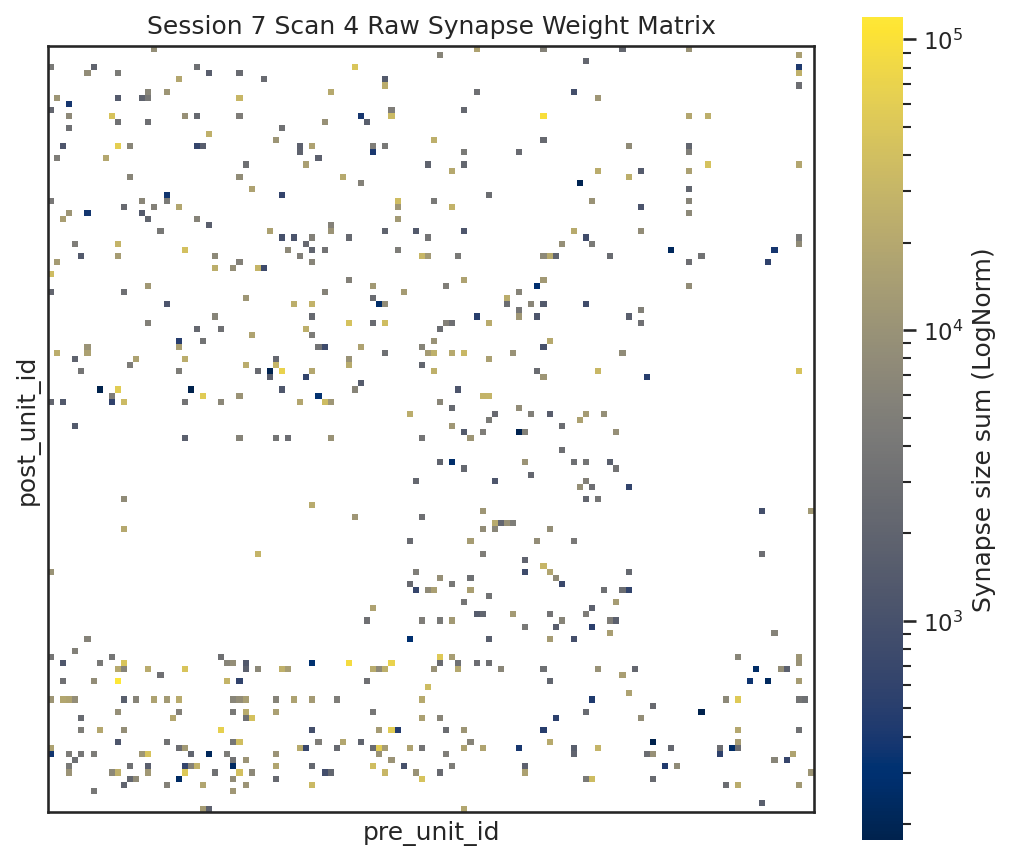

Saved: /notebooks/workspace/outputs_v1_col_7_4/structural_coupling/2026-05-03/correlation/V1_col_7_4_synapse_weight_matrix_heatmap.png


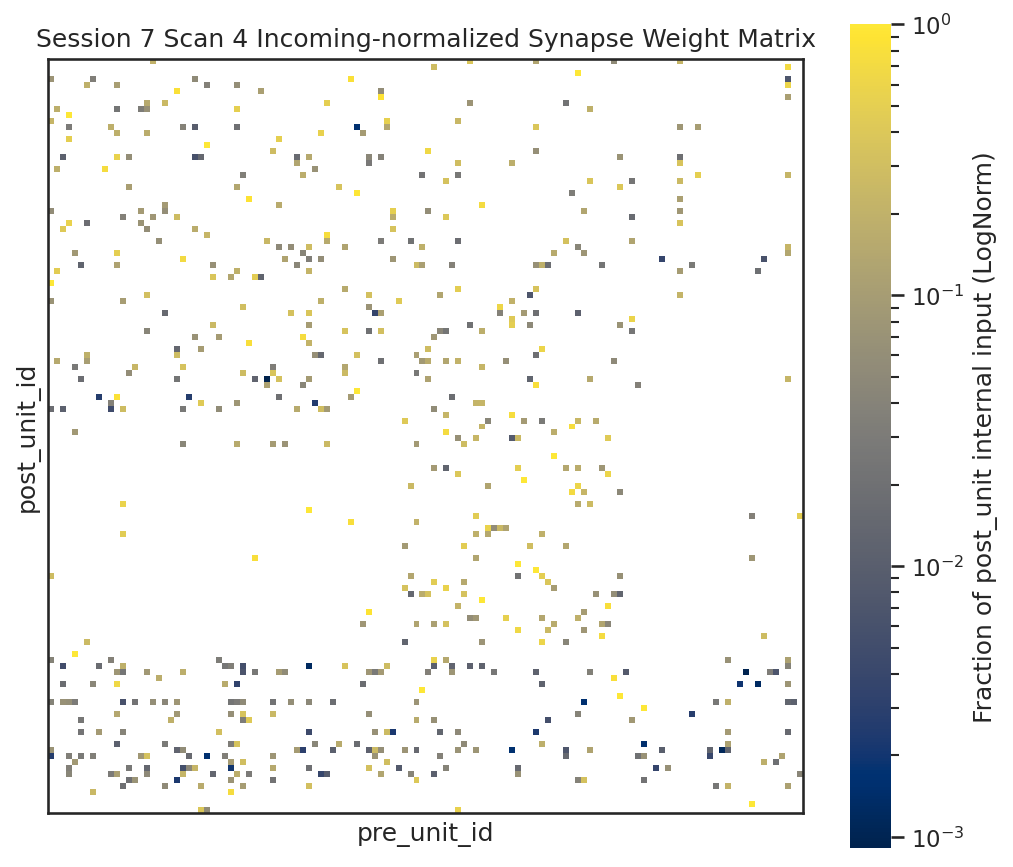

Saved: /notebooks/workspace/outputs_v1_col_7_4/structural_coupling/2026-05-03/correlation/V1_col_7_4_synapse_weight_matrix_incoming_norm_heatmap.png


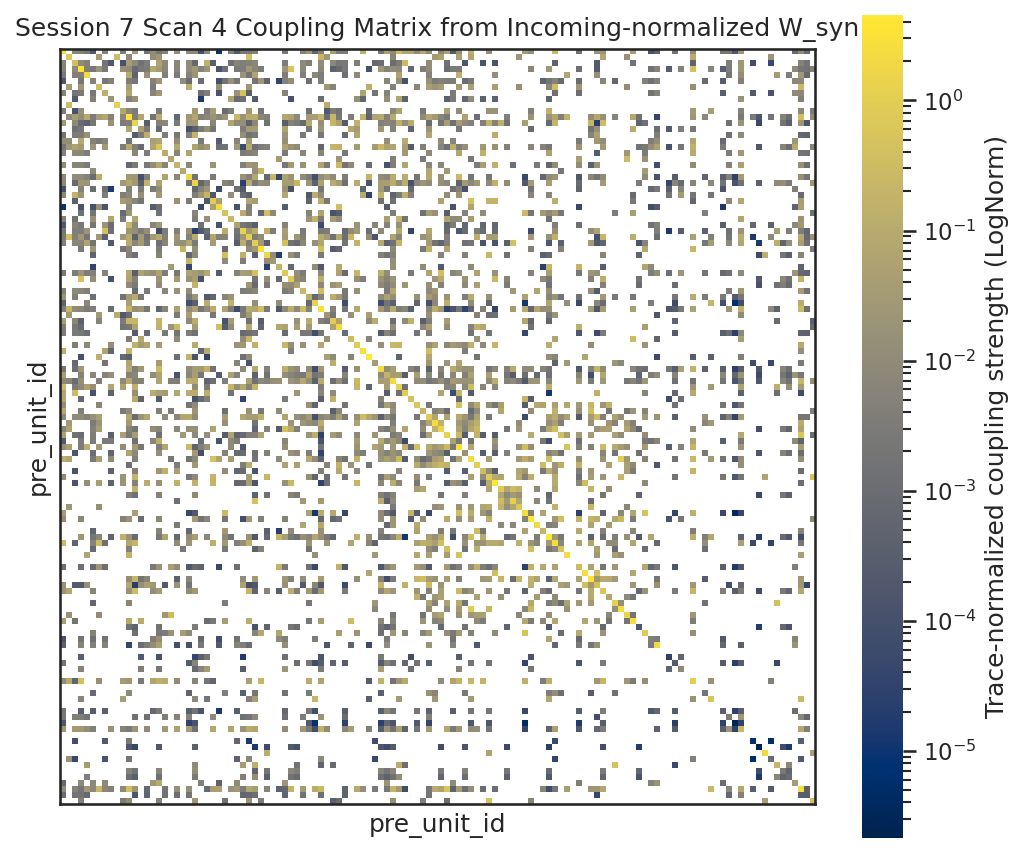

Saved: /notebooks/workspace/outputs_v1_col_7_4/structural_coupling/2026-05-03/coupling-eigen/V1_col_7_4_coupling_matrix_incoming_norm_heatmap.png


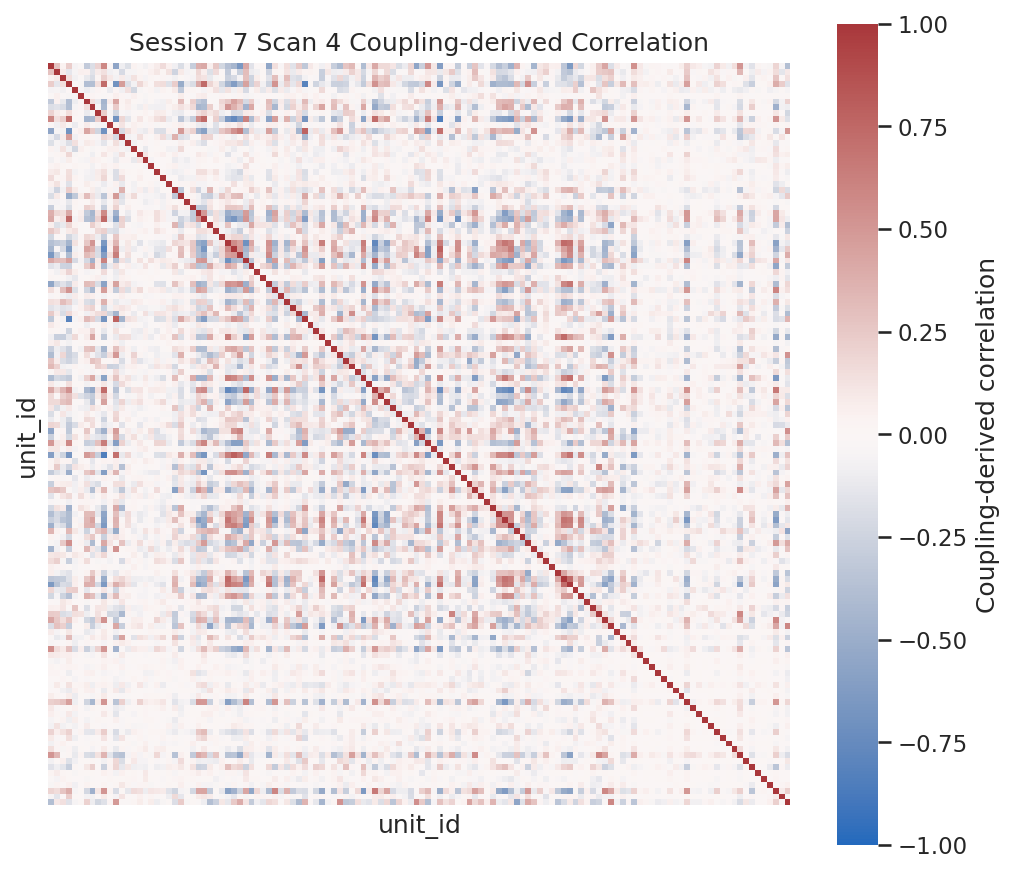

Saved: /notebooks/workspace/outputs_v1_col_7_4/structural_coupling/2026-05-03/coupling-eigen/V1_col_7_4_coupling_derived_correlation_heatmap_incoming_norm.png


In [8]:
def plot_positive_log_matrix(
    matrix_df: pd.DataFrame,
    title: str,
    colorbar_label: str,
    output_path: Path,
    xlabel: str,
    ylabel: str,
):
    data = matrix_df.to_numpy(dtype=float)
    positive = data[data > 0]
    if positive.size == 0:
        raise ValueError(f"{title} has no positive entries for LogNorm visualization.")
    masked = np.ma.masked_where(data <= 0, data)

    fig, ax = plt.subplots(figsize=(7, 6), dpi=150)
    im = ax.imshow(
        masked,
        cmap="cividis",
        norm=colors.LogNorm(vmin=float(positive.min()), vmax=float(positive.max())),
        aspect="equal",
        interpolation="nearest",
        rasterized=True,
    )
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xticks([])
    ax.set_yticks([])
    cb = fig.colorbar(im, ax=ax, label=colorbar_label)
    cb.outline.set_linewidth(0)
    fig.tight_layout()
    fig.savefig(output_path, bbox_inches="tight")
    plt.show()
    print("Saved:", output_path)

plot_positive_log_matrix(
    W_syn_unit_df,
    "Session 7 Scan 4 Raw Synapse Weight Matrix",
    f"Synapse {synapse_weight_col} sum (LogNorm)",
    STRUCTURAL_CORRELATION_OUTDIR / "V1_col_7_4_synapse_weight_matrix_heatmap.png",
    xlabel="pre_unit_id",
    ylabel="post_unit_id",
)

plot_positive_log_matrix(
    W_syn_incoming_norm_df,
    "Session 7 Scan 4 Incoming-normalized Synapse Weight Matrix",
    "Fraction of post_unit internal input (LogNorm)",
    STRUCTURAL_CORRELATION_OUTDIR / "V1_col_7_4_synapse_weight_matrix_incoming_norm_heatmap.png",
    xlabel="pre_unit_id",
    ylabel="post_unit_id",
)

plot_positive_log_matrix(
    Coupling,
    "Session 7 Scan 4 Coupling Matrix from Incoming-normalized W_syn",
    "Trace-normalized coupling strength (LogNorm)",
    STRUCTURAL_COUPLING_EIGEN_OUTDIR / "V1_col_7_4_coupling_matrix_incoming_norm_heatmap.png",
    xlabel="pre_unit_id",
    ylabel="pre_unit_id",
)

fig, ax = plt.subplots(figsize=(7, 6), dpi=150)
sns.heatmap(
    coupling_corr_df,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    xticklabels=False,
    yticklabels=False,
    square=True,
    cbar_kws={"label": "Coupling-derived correlation"},
    ax=ax,
)
ax.set_title("Session 7 Scan 4 Coupling-derived Correlation")
ax.set_xlabel("unit_id")
ax.set_ylabel("unit_id")
fig.tight_layout()
coupling_corr_heatmap = STRUCTURAL_COUPLING_EIGEN_OUTDIR / "V1_col_7_4_coupling_derived_correlation_heatmap_incoming_norm.png"
fig.savefig(coupling_corr_heatmap, bbox_inches="tight")
plt.show()
print("Saved:", coupling_corr_heatmap)

if "corr_df" in globals():
    common_units = corr_df.index.astype(int).intersection(coupling_corr_df.index.astype(int))
    empirical = corr_df.loc[common_units, common_units].to_numpy(dtype=float)
    model = coupling_corr_df.loc[common_units, common_units].to_numpy(dtype=float)
    tri = np.triu_indices_from(empirical, k=1)
    alignment_r = np.corrcoef(empirical[tri], model[tri])[0, 1]
    print(f"Empirical functional correlation vs coupling-derived correlation, upper-triangle Pearson r: {alignment_r:.4f}")


## 6. Coupling 与 coupling-derived correlation 的 eigenspectrum

沿用 `subsampling.py`：对原始矩阵计算特征值，并对 `k_fraction = 0.125, 0.25, 0.5` 的随机子采样矩阵重复计算 eigenspectrum。power-law fit 只使用严格为正的 top eigenvalues。



Saved: /notebooks/workspace/outputs_v1_col_7_4/structural_coupling/2026-05-03/coupling-eigen/V1_col_7_4_coupling_derived_correlation_eigenspectrum_incoming_norm.csv
Saved: /notebooks/workspace/outputs_v1_col_7_4/structural_coupling/2026-05-03/coupling-eigen/V1_col_7_4_coupling_matrix_eigenspectrum_incoming_norm.csv


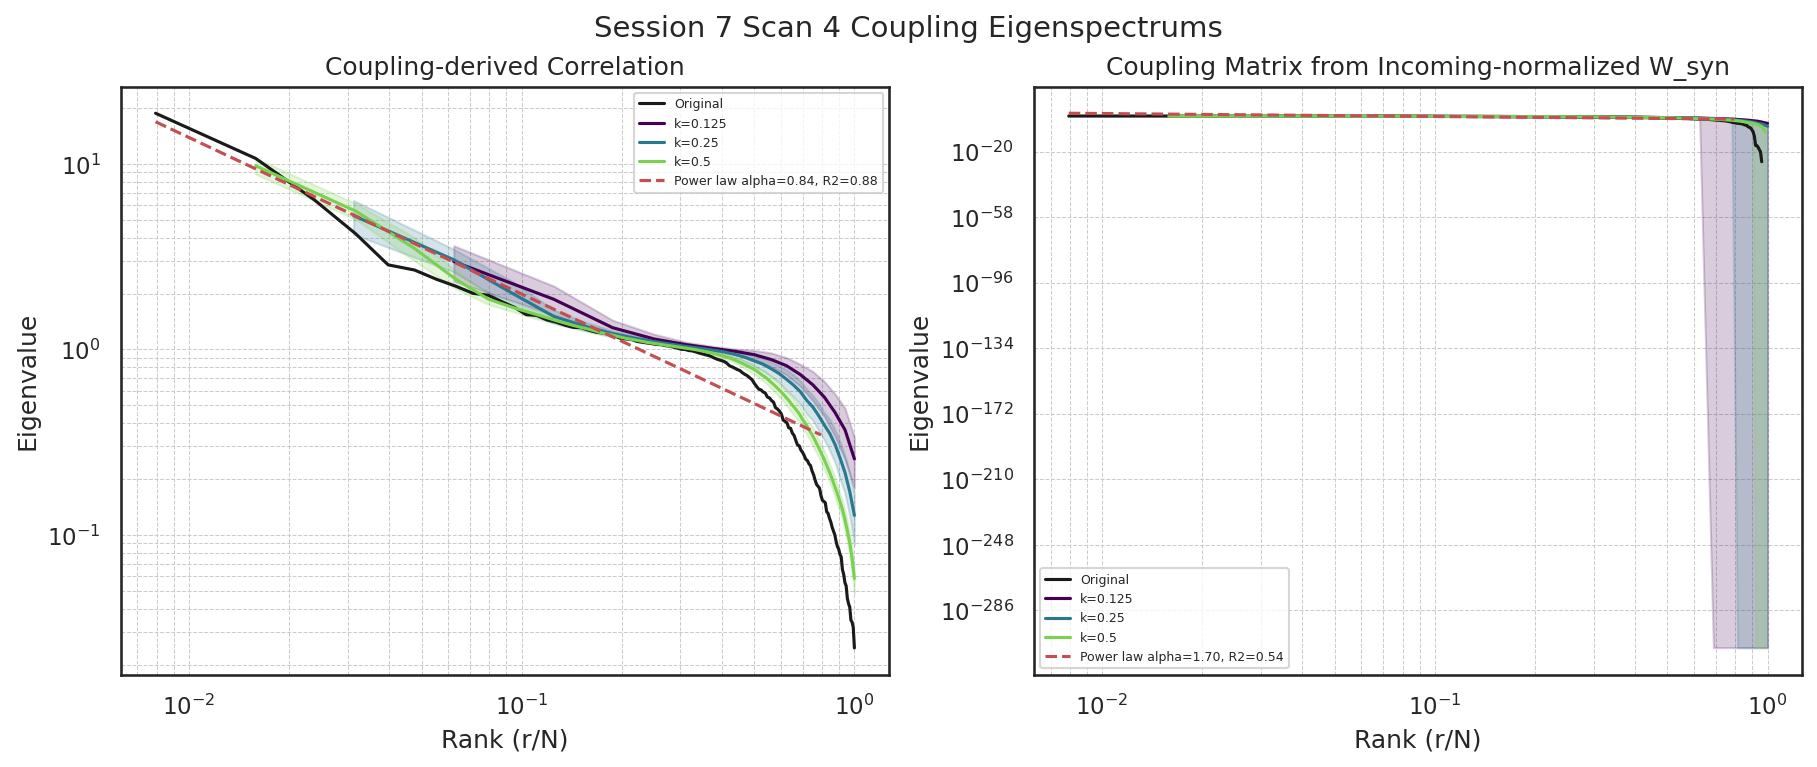

Saved: /notebooks/workspace/outputs_v1_col_7_4/structural_coupling/2026-05-03/coupling-eigen/V1_col_7_4_coupling_eigenspectrums_incoming_norm.png


In [9]:
def eigenspectrum_desc(matrix: np.ndarray) -> np.ndarray:
    evals = np.linalg.eigvalsh(matrix)
    return np.sort(evals)[::-1]


def fit_power_law_positive(eigenvalues: np.ndarray, num_top_eigenvalues: int = 100):
    evals = np.sort(np.asarray(eigenvalues, dtype=float))[::-1]
    positive_positions = np.flatnonzero(evals > 0)
    n_fit = min(num_top_eigenvalues, len(positive_positions))
    if n_fit < 2:
        return None
    fit_positions = positive_positions[:n_fit]
    top_evals = evals[fit_positions]
    normalized_ranks = (fit_positions + 1) / len(evals)
    log_x = np.log(normalized_ranks)
    log_y = np.log(top_evals)
    slope, intercept = np.polyfit(log_x, log_y, 1)
    fitted_y = np.exp(slope * log_x + intercept)
    r_squared = np.corrcoef(log_x, log_y)[0, 1] ** 2
    return {
        "slope": slope,
        "intercept": intercept,
        "exponent": -slope,
        "r_squared": r_squared,
        "data_x": normalized_ranks,
        "data_y": top_evals,
        "fitted_y": fitted_y,
    }


def save_eigenspectrum_csv(eigenvalues: np.ndarray, output_path: Path):
    ranks = np.arange(1, len(eigenvalues) + 1)
    df = pd.DataFrame({
        "rank": ranks,
        "rank_normalized": ranks / len(eigenvalues),
        "eigenvalue": eigenvalues,
    })
    df.to_csv(output_path, index=False)
    print("Saved:", output_path)
    return df


def plot_positive_eigenvalues(axis, ranks, eigenvalues, *args, **kwargs):
    eigenvalues = np.asarray(eigenvalues, dtype=float)
    ranks = np.asarray(ranks, dtype=float)
    positive = np.isfinite(eigenvalues) & (eigenvalues > 0) & np.isfinite(ranks) & (ranks > 0)
    if positive.any():
        axis.loglog(ranks[positive], eigenvalues[positive], *args, **kwargs)


coupling_corr_evals = eigenspectrum_desc(CouplingCorrelationMatrix)
coupling_evals = eigenspectrum_desc(CouplingMatrix)
save_eigenspectrum_csv(
    coupling_corr_evals,
    STRUCTURAL_COUPLING_EIGEN_OUTDIR / "V1_col_7_4_coupling_derived_correlation_eigenspectrum_incoming_norm.csv",
)
save_eigenspectrum_csv(
    coupling_evals,
    STRUCTURAL_COUPLING_EIGEN_OUTDIR / "V1_col_7_4_coupling_matrix_eigenspectrum_incoming_norm.csv",
)
fit_corr = fit_power_law_positive(coupling_corr_evals, num_top_eigenvalues=100)
fit_coupling = fit_power_law_positive(coupling_evals, num_top_eigenvalues=100)

k_fractions = [0.125, 0.25, 0.5]
n_iter = 50
subsample_seed = 43
fig, ax = plt.subplots(1, 2, figsize=(12, 5), dpi=150, constrained_layout=True)
fig.suptitle("Session 7 Scan 4 Coupling Eigenspectrums", fontsize=14)

for axis, matrix, evals, fit, title in [
    (ax[0], CouplingCorrelationMatrix, coupling_corr_evals, fit_corr, "Coupling-derived Correlation"),
    (ax[1], CouplingMatrix, coupling_evals, fit_coupling, "Coupling Matrix from Incoming-normalized W_syn"),
]:
    ranks = (np.arange(len(evals)) + 1) / len(evals)
    plot_positive_eigenvalues(axis, ranks, evals, "k-", linewidth=1.5, label="Original")

    colors_sub = plt.cm.viridis(np.linspace(0, 0.8, len(k_fractions)))
    for idx, k_fraction in enumerate(k_fractions):
        mean_evals, std_evals, _ = subsampling.get_subsampled_eigenspectrum(
            matrix,
            k_fraction,
            n_iter=n_iter,
            seed=subsample_seed + idx,
        )
        ranks_sub = (np.arange(len(mean_evals)) + 1) / len(mean_evals)
        upper = mean_evals + std_evals
        lower = mean_evals - std_evals
        positive = np.isfinite(mean_evals) & (mean_evals > 0) & np.isfinite(upper) & (upper > 0)
        if positive.any():
            safe_lower = np.maximum(lower[positive], np.finfo(float).tiny)
            axis.loglog(ranks_sub[positive], mean_evals[positive], color=colors_sub[idx], linewidth=1.5, label=f"k={k_fraction}")
            axis.fill_between(ranks_sub[positive], safe_lower, upper[positive], color=colors_sub[idx], alpha=0.2)

    if fit is not None:
        axis.loglog(
            fit["data_x"],
            fit["fitted_y"],
            "r--",
            linewidth=1.5,
            label="Power law alpha={:.2f}, R2={:.2f}".format(fit["exponent"], fit["r_squared"]),
        )

    axis.set_xlabel("Rank (r/N)")
    axis.set_ylabel("Eigenvalue")
    axis.set_title(title)
    axis.grid(True, which="both", linestyle="--", linewidth=0.5)
    axis.legend(fontsize=6)

eigenspectrum_path = STRUCTURAL_COUPLING_EIGEN_OUTDIR / "V1_col_7_4_coupling_eigenspectrums_incoming_norm.png"
fig.savefig(eigenspectrum_path, bbox_inches="tight")
plt.show()
print("Saved:", eigenspectrum_path)
